<a href="https://colab.research.google.com/github/DrStephPowers/BIA/blob/main/Ch10_Pictorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Face Decomposition

### Import Dataset

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
olivetti_faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [ ]:
olivetti_faces.data.shape

(400, 4096)

In [ ]:
olivetti_faces.target.shape

(400,)

In [ ]:
olivetti_faces.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [ ]:
olivetti_faces.images.shape

(400, 64, 64)

### Center the Faces

In [ ]:
faces, _ = fetch_olivetti_faces(return_X_y=True)
n_samples, n_features = faces.shape

In [ ]:
faces = faces.astype('float64')/255.0

In [ ]:
faces_center = faces - faces.mean(axis=0)
faces_center -= faces_center.mean(axis=1).reshape(n_samples, -1)

### Example Face

In [ ]:
examp = faces_center[2]

In [ ]:
examp_image= np.reshape(np.ravel(examp), (64, 64))

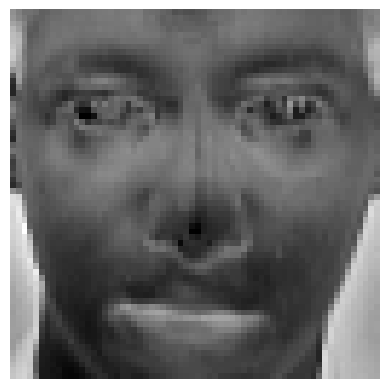

In [ ]:
plt.imshow(examp_image,cmap="binary")
plt.axis("off")
plt.show()

### Testing and Training Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(faces_center, olivetti_faces.target, test_size=0.2, shuffle=True)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

### Eigenfaces using PCA

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=150)
pca.fit(x_train)

PCA(n_components=150)

In [ ]:
examp = pca.components_[5]

In [ ]:
examp_image= np.reshape(np.ravel(examp), (64, 64))

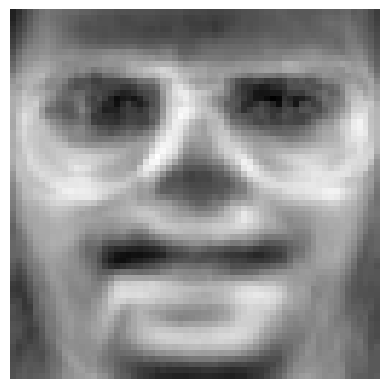

In [ ]:
plt.imshow(examp_image,cmap="binary")
plt.axis("off")
plt.show()

## Face Recognition (Classification Using SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [ ]:
svm = SVC()
svm.fit(x_train_pca, y_train)

SVC()

In [ ]:
y_pred = svm.predict(x_test_pca)
y_pred

array([33, 22, 33, 17, 17, 36, 27, 35, 16, 39, 34, 27,  7,  6,  0,  6, 14,
       35,  8, 39, 37, 27, 28,  9, 11,  9, 15,  5, 19, 15, 33, 39, 37,  7,
       24,  3, 23, 17, 26, 14,  8, 29, 37, 21, 11, 24, 15, 38,  6, 11,  1,
       33, 32, 23, 23, 39,  5, 16,  0, 13,  1,  8, 34, 20, 21, 14, 16,  8,
       13, 29, 11, 29, 10, 31, 24, 36, 12, 23, 32,  1])

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9

In [ ]:
y_pred[3]

np.int64(17)

In [ ]:
y_test[3]

np.int64(17)

## Siamese Neural Network

In [ ]:
from collections import defaultdict
import random
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from keras import layers
from keras.layers import Input, Dense, Lambda, Concatenate

In [ ]:
batch_size=32
num_triplets=1000

In [ ]:
def generate_triplets(x, y):

  class_indices = defaultdict(list)

  for idx, label in enumerate(y):
    class_indices[label].append(idx)

  classes = list(class_indices.keys())

  triplets = []

  for _ in range(num_triplets):
    # Select anchor class
    anchor_class = random.choice(classes)

    # Ensure we have at least 2 samples for this class
    if len(class_indices[anchor_class]) < 2:
      continue

    # Select anchor and positive from same class
    anchor_idx, positive_idx = random.sample(class_indices[anchor_class], 2)

    # Select negative from different class
    negative_class = random.choice([c for c in classes if c != anchor_class])
    negative_idx = random.choice(class_indices[negative_class])

    triplets.append({
      'anchor': x[anchor_idx],
      'positive': x[positive_idx],
      'negative': x[negative_idx]})

  return triplets

In [ ]:
def get_batch(num_triplets):
    triplets = generate_triplets(num_triplets)

    anchors = np.array([t['anchor'] for t in triplets])
    positives = np.array([t['positive'] for t in triplets])
    negatives = np.array([t['negative'] for t in triplets])

    return [anchors, positives, negatives]

In [ ]:
def triplet_loss(margin=1.0):
    def loss(y_true, y_pred):
        anchor, positive, negative = tf.split(y_pred, num_or_size_splits=3, axis=1)

        # Calculate distances
        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1, keepdims=True)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1, keepdims=True)

        # Triplet loss
        basic_loss = pos_dist - neg_dist + margin
        loss = tf.reduce_mean(tf.maximum(basic_loss, 0.0))

        return loss
    return loss

In [ ]:
def create_base_network(input_dim):
    model = Sequential([
        Dense(512, activation='relu', input_shape=(input_dim,)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='linear')
    ])
    return model

In [ ]:
# Build Siamese network
def build_siamese_network(input_dim):
    base_network = create_base_network(input_dim)

    # Define inputs
    input_anchor = Input(shape=(input_dim,), name='anchor')
    input_positive = Input(shape=(input_dim,), name='positive')
    input_negative = Input(shape=(input_dim,), name='negative')

    # Generate embeddings
    embedding_anchor = base_network(input_anchor)
    embedding_positive = base_network(input_positive)
    embedding_negative = base_network(input_negative)

    # Concatenate embeddings for loss calculation
    output = Concatenate(axis=1)([embedding_anchor, embedding_positive, embedding_negative])

    # Create model
    model = Model(inputs=[input_anchor, input_positive, input_negative], outputs=output)

    return model, base_network

In [ ]:
input_dim = 150  # PCA components dimension
siamese_model, base_network = build_siamese_network(input_dim)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
siamese_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss(margin=1.0))

In [ ]:
siamese_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 150)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 150)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 64)        │    249,792 │ anchor[0][0],     │
│ (Sequential)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 192)       │          0 │ sequential_8[0][… │
│ (Concatenate)       │                   │            │ sequential_8[1][… │
│                     │                   │            │ sequential_8[2][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 249,792 (975.75 KB)

 Trainable params: 249,792 (975.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
triplet_gen = generate_triplets(x_train_pca, y_train)

In [ ]:
epochs = 200
triplets_per_epoch = 1000

In [ ]:
history = []

for epoch in range(epochs):
    # Generate triplets for this epoch
    batch = generate_triplets(x_train_pca, y_train)

    # Dummy labels (not used in triplet loss)
    dummy_labels = np.zeros((triplets_per_epoch, 192))  # 64*3 for concatenated embeddings

    # Prepare the input for train_on_batch as a list of arrays
    batch_input = [np.array([t['anchor'] for t in batch]),
                   np.array([t['positive'] for t in batch]),
                   np.array([t['negative'] for t in batch])]

    # Train on this batch
    loss = siamese_model.train_on_batch(batch_input, dummy_labels)
    history.append(loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss:.4f}")

Epoch 0/200, Loss: 0.7026
Epoch 10/200, Loss: 0.6599
Epoch 20/200, Loss: 0.6223
Epoch 30/200, Loss: 0.5885
Epoch 40/200, Loss: 0.5581
Epoch 50/200, Loss: 0.5307
Epoch 60/200, Loss: 0.5061
Epoch 70/200, Loss: 0.4838
Epoch 80/200, Loss: 0.4630
Epoch 90/200, Loss: 0.4441
Epoch 100/200, Loss: 0.4265
Epoch 110/200, Loss: 0.4103
Epoch 120/200, Loss: 0.3954
Epoch 130/200, Loss: 0.3817
Epoch 140/200, Loss: 0.3688
Epoch 150/200, Loss: 0.3566
Epoch 160/200, Loss: 0.3452
Epoch 170/200, Loss: 0.3345
Epoch 180/200, Loss: 0.3245
Epoch 190/200, Loss: 0.3150


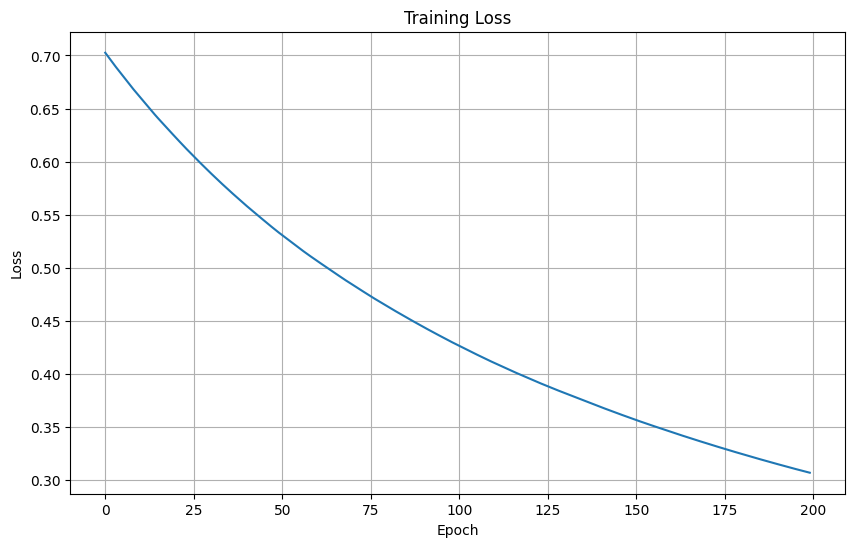

In [ ]:
  plt.figure(figsize=(10, 6))
  plt.plot(history)
  plt.title('Training Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.grid(True)
  plt.show()

In [ ]:
def compute_distance(embedding1, embedding2):
    return np.linalg.norm(embedding1 - embedding2)

In [ ]:
test_embeddings = base_network.predict(x_test_pca)

threshold = 0.5
correct_predictions = 0
total_predictions = 0

# Test with pairs from same and different classes
for i in range(len(x_test_pca)):
    for j in range(i+1, min(i+20, len(x_test_pca))):  # Test with subset for efficiency
        dist = compute_distance(test_embeddings[i], test_embeddings[j])
        same_person = (y_test[i] == y_test[j])
        predicted_same = (dist < threshold)

        if same_person == predicted_same:
            correct_predictions += 1
        total_predictions += 1

accuracy = correct_predictions / total_predictions
accuracy


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


0.9781954887218045

In [ ]:
def demonstrate_recognition(base_network, x_test_pca, y_test, faces_test_reshaped, num_examples=5):
    test_embeddings = base_network.predict(x_test_pca)

    fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4*num_examples))

    for i in range(num_examples):
        # Select a query image
        query_idx = i
        query_embedding = test_embeddings[query_idx]
        query_label = y_test[query_idx]

        # Find most similar images
        distances = [compute_distance(query_embedding, test_embeddings[j])
                    for j in range(len(test_embeddings))]

        # Get indices of most similar images (excluding the query itself)
        similar_indices = np.argsort(distances)[1:4]  # Top 3 similar (excluding self)

        # Plot query image
        axes[i, 0].imshow(faces_test_reshaped[query_idx], cmap='gray')
        axes[i, 0].set_title(f'Query (Person {query_label})')
        axes[i, 0].axis('off')

        # Plot most similar images
        for j, idx in enumerate(similar_indices):
            axes[i, j+1].imshow(faces_test_reshaped[idx], cmap='gray')
            match_status = "✓" if y_test[idx] == query_label else "✗"
            axes[i, j+1].set_title(f'{match_status} Person {y_test[idx]}\nDist: {distances[idx]:.2f}')
            axes[i, j+1].axis('off')

    plt.tight_layout()
    plt.show()


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


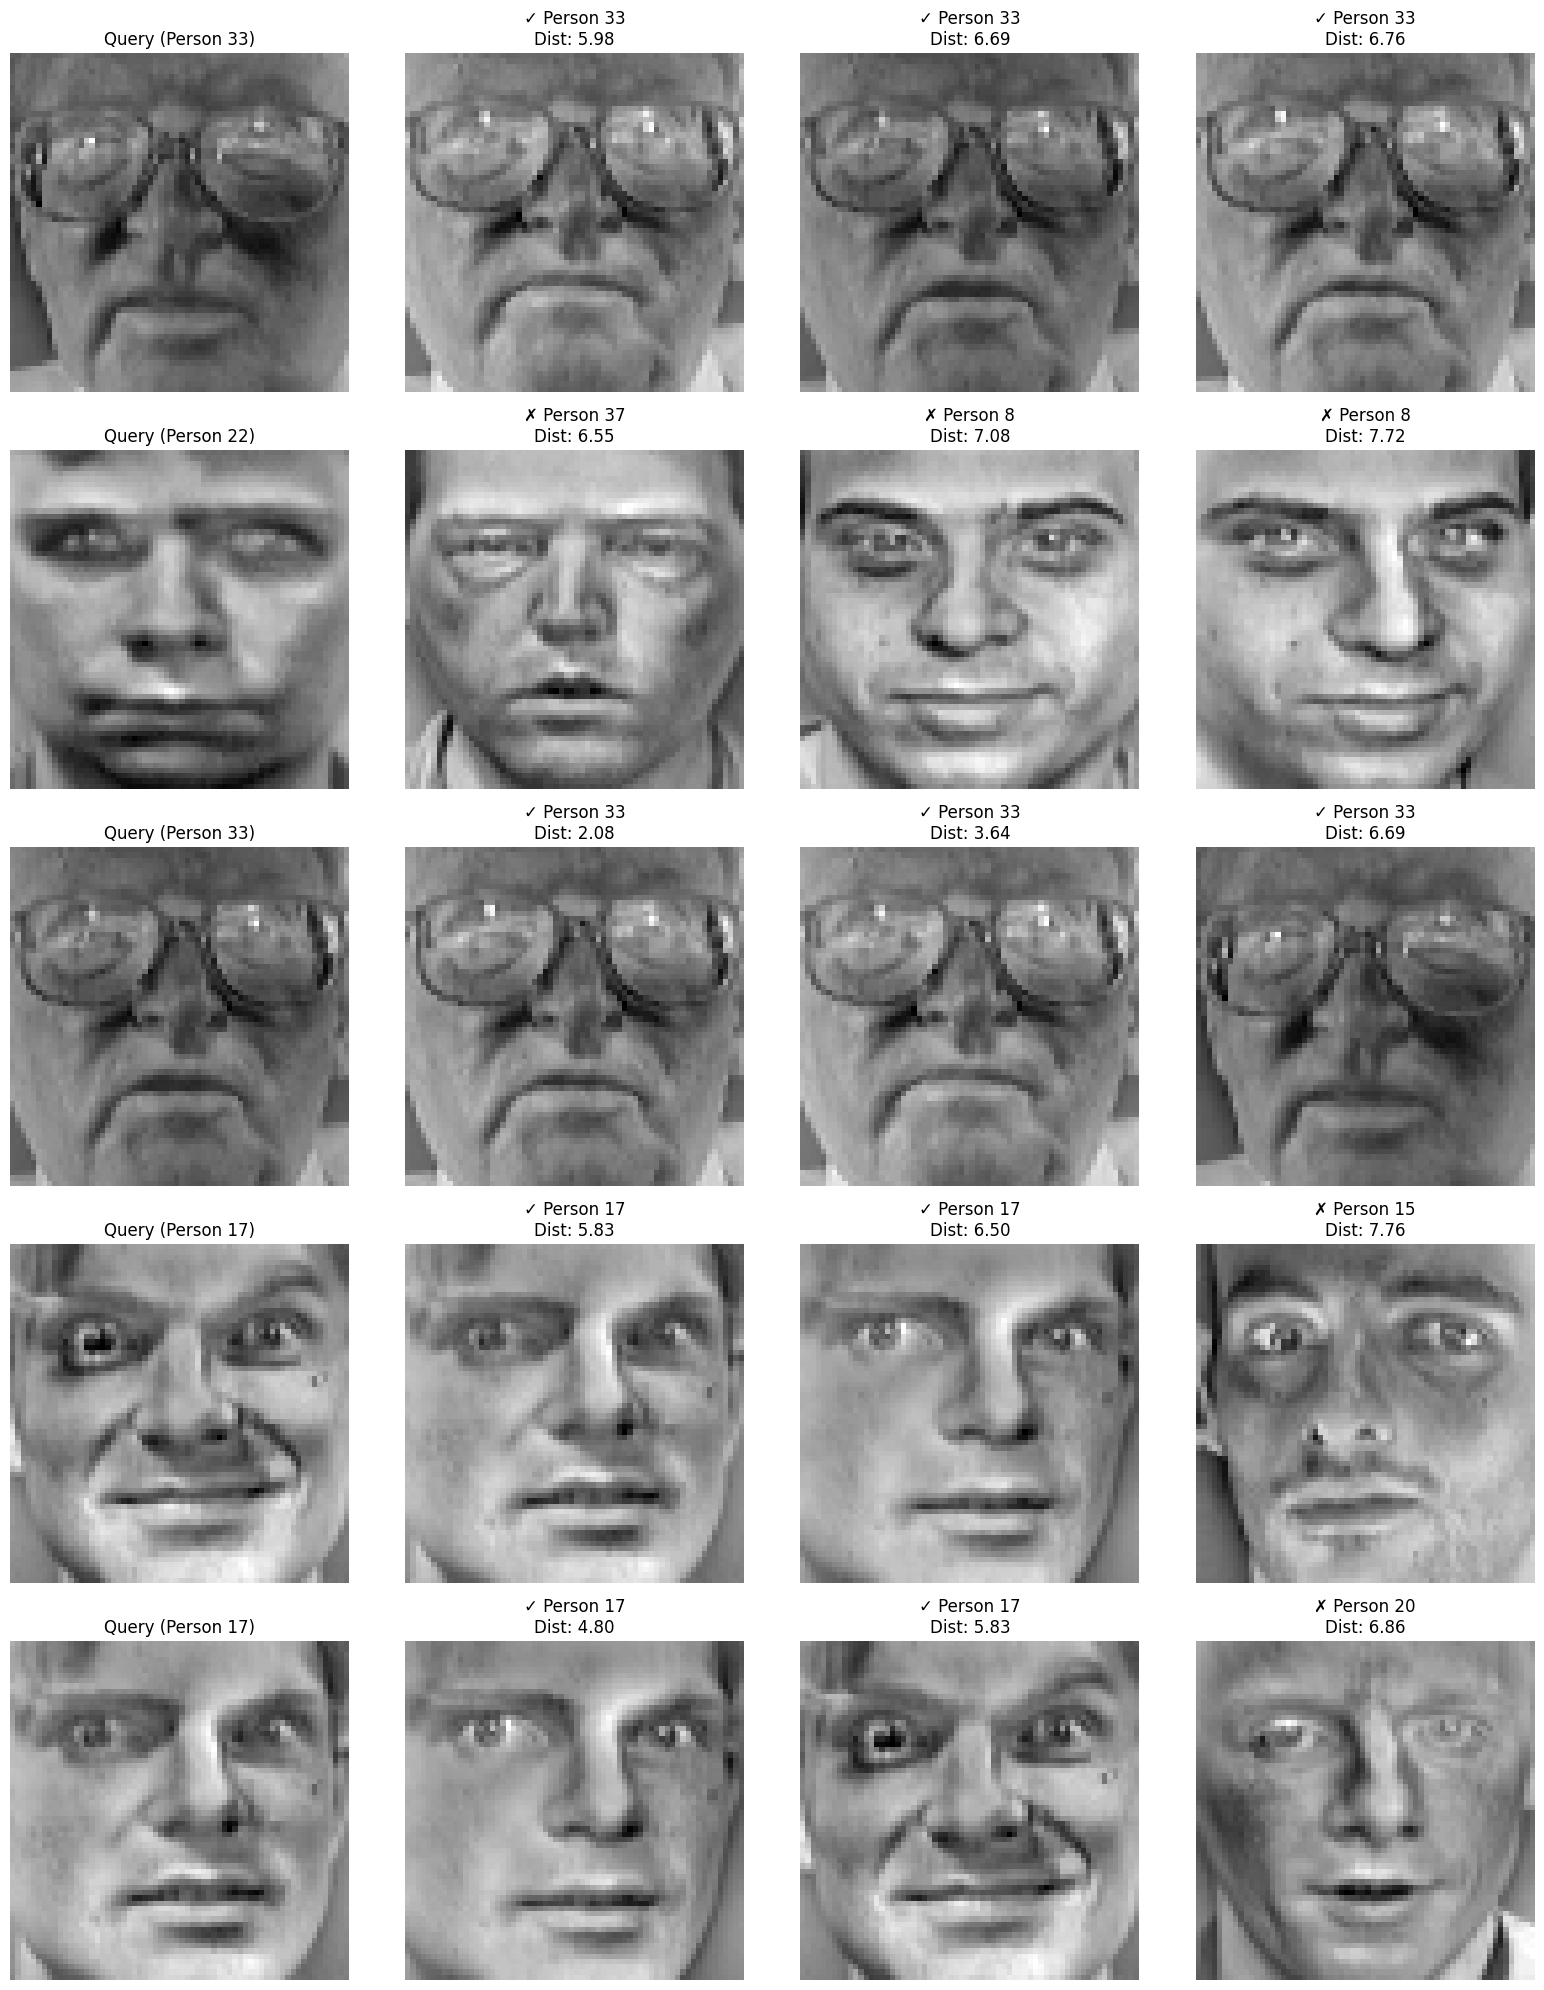

In [ ]:
faces_test_reshaped = x_test.reshape(-1, 64, 64)
demonstrate_recognition(base_network, x_test_pca, y_test, faces_test_reshaped)


Try creating a facial recognition algorithm with the Caltech dataset. How accurate is it?

https://data.caltech.edu/records/6rjah-hdv18